In [168]:
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [169]:
from tavily import TavilyClient
from pydantic import BaseModel

class StockNewsItem(BaseModel):
    id: int
    ticker: str
    company_name: str
    title: str
    content: str
    raw_content: str
    url: str
    published_date: str


tavily_client = TavilyClient();

# Domain preset
DOMAIN_PRESETS = {
    "general": [
        "reuters.com",
        "cnbc.com",
        "finance.yahoo.com",
        "marketwatch.com",
        "bloomberg.com",
    ],
    "deep_analysis": [
        "seekingalpha.com",
        "barrons.com",
        "wsj.com",
        "morningstar.com",
        "ft.com",
    ],
    "realtime": [
        "cnbc.com",
        "benzinga.com",
        "finance.yahoo.com",
        "marketwatch.com",
        "thestreet.com",
    ],
    "mix_and_match":[
        "bloomberg.com",
        "reuters.com",
        "wsj.com",
        "ft.com",
        "cnbc.com",
        "finance.yahoo.com"
    ]
}

def search_stock_news(ticker: str, company_name: str, max_results: int) -> list[StockNewsItem]:
    """return the most recent news limited by number"""
    
    domains = DOMAIN_PRESETS["deep_analysis"]
    query = f'{company_name} ({ticker}) latest stock news'

    response = tavily_client.search(query=query, 
                                    topic="news", 
                                    max_results=max_results,
                                    search_depth="basic",
                                    include_raw_content="markdown",
                                    days = 3,
                                    include_domains=domains)
    
    results = [StockNewsItem(
        id = idx,
        ticker=ticker,
        company_name=company_name,
        title=r['title'],
        content=r['content'],
        raw_content=r['raw_content'],
        url=r['url'],
        published_date=r['published_date']
    ) for idx, r in enumerate(response['results'])]
   
    return results



In [ ]:
from langgraph.graph.message import add_messages

class NewsItems(BaseModel):
    id: int
    title: str
    content: str    
    raw_content: str
    summary: str
    summary_kr: str
    published_date: str
    url: str
    sentiment_label: str
    sentiment_score: float


def merge_news_items(existing: list[NewsItems], new: list) -> list[NewsItems]:
    """Merge new news items into existing list, updating fields if item id already exists."""
    existing_map = {item.id: item for item in existing}
    
    for new_item in new:
        new_dict = new_item.model_dump()

        if new_dict.get('id') in existing_map:            
            existing_map[new_dict['id']] = existing_map[new_dict['id']].model_copy(
                update={k: v for k, v in new_dict.items() if v is not None}
            )
        else:
            existing_map[new_dict['id']] = NewsItems(**new_dict)
    
    return list(existing_map.values())

In [172]:
#define GraphState
from typing import Optional, Annotated
from pydantic import BaseModel, Field

class StockNewsState(BaseModel):
    ticker: str = Field(description="Ticker symbol. e.g. SNDK, APPL")
    company_name: Optional[str] = Field(default=None, description="The company name from the ticker symbol. e.g. Apple, inc.")
    news_items: Annotated[Optional[list[NewsItems]], merge_news_items] = Field(default_factory=list)

In [173]:
from app.utils.financial import get_company_name

def load_news(state: StockNewsState):
    """Load news from data base if news exist; fill the state"""
    return {}

def route_messages(state: StockNewsState):
    """if there are news items in the state go to END; otherwise, go grab news!"""
    if(state.news_items):
        return 'end'
    return 'search_news'


def search_news(state: StockNewsState):
    """Search Top 3 news"""
    company_name = get_company_name(state.ticker)
    stock_news = search_stock_news(state.ticker, company_name, 3)

    news_items = [NewsItems(
            id=idx,
            title=n.title,
            content=n.content,
            content_kr='',
            raw_content=n.raw_content,
            summary='',
            summary_kr='',
            published_date=n.published_date,
            url=n.url,
            sentiment_label='',
            sentiment_score=0.0
            ) for idx, n in enumerate(stock_news)]                  
    
    return {"company_name": company_name, "news_items":news_items}


def save_to_db(state: StockNewsState):
    """Save the data to supadb"""
    print(state)
    return {}

In [174]:
from langchain_core.prompts import ChatPromptTemplate
from app.utils.llm_models import get_ollama_llm
from pydantic import BaseModel, Field
from typing import List, Literal

# Model output schema
class NewAnalysis(BaseModel):
    id: int = Field(description="the article id")
    title: str = Field(description="A title of the article")
    summary: str = Field(description="A concise summary of the article in 2-3 sentences (English)")
    summary_kr: str = Field(description="Korean translation of the summary")    
    sentiment_label: Literal["Positive", "Negative", "Neutral"] = Field(description="Sentiment analysis result - must of one of: 'Positive', 'Negative', 'Neutral'")
    sentiment_score: float = Field(description="Sentiment confidence score between -1.0 (most negative) and 1.0 (most positive)")

class NewsAnalysisList(BaseModel):
    articles: List[NewAnalysis]


def summarize_news(state: StockNewsState):
    """Summarize 3 news and add sentiment and embedding"""


    news_content = "\n\n".join([f"Article {n.id}: \nTitle: {n.title}\nContent: {n.raw_content}\nURL:{n.url}\nDate: {n.published_date}"
                                for n in state.news_items
                                ]).replace("{","{{").replace("}","}}")  
    
    prompt = f"""
    You are a financial news analyst. Analyze the following news articles about {state.ticker} ({state.company_name})

    For each article, provide:

    1. **id**: the article id
    2. **title**: A title of the article
    3. **summary**: A concise summary of the article in 4-5 sentences (English)
    4. **summary_kr**: Korean translation of the summary    
    5. **sentiment_label**: Sentiment analysis result - must of one of: 'Positive', 'Negative', 'Neutral'
    6. **sentiment_score**: Sentiment confidence score between -1.0 (most negative) and 1.0 (most positive)

    News Articles:
    {news_content}   

    Return a JSON object with an "articles" key containing the list of results.
    """

    prompt_template = ChatPromptTemplate.from_messages([
        ("system", "You are a financial news analyst specializing in stock market analysis."),
        ("user", prompt)
    ])

      
    llm = get_ollama_llm()
    llm_with_structure = llm.with_structured_output(NewsAnalysisList)

    chain = prompt_template | llm_with_structure

    response = chain.invoke({
        "ticker": state.ticker,
        "company_name": state.company_name,
        "news_content": news_content
    })
   
    return {"news_items": response.articles}


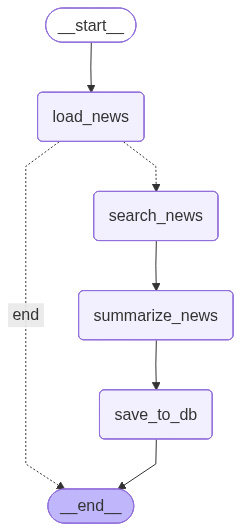

In [175]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
builder = StateGraph(StockNewsState)
builder.add_node("load_news", load_news)
#builder.add_node("route_messages", route_messages)
builder.add_node("search_news", search_news)
builder.add_node("summarize_news", summarize_news)
builder.add_node("save_to_db", save_to_db)

builder.add_edge(START, "load_news")
#builder.add_edge("load_news","route_messages")
#builder.add_conditional_edges("route_messages", route_messages, {"search_news": "search_news", "end": END})
builder.add_conditional_edges("load_news",route_messages,{"search_news": "search_news", "end":END})
builder.add_edge("search_news","summarize_news")
builder.add_edge("summarize_news", "save_to_db")
builder.add_edge("save_to_db", END)

stock_news_graph = builder.compile()

display(Image(stock_news_graph.get_graph(xray=1).draw_mermaid_png()))


In [176]:
result= stock_news_graph.invoke({"ticker": "SNDK", "company_name": ""})

ticker='SNDK' company_name='Sandisk Corporation' news_items=[NewsItems(id=0, title='STMicroelectronics Shares Rally After Chip Maker Raises Data-Center Revenue Target', content='# STMicroelectronics Shares Rally After Chip Maker Raises Data-Center Revenue Target - WSJ. This copy is for your personal, non-commercial use only. For non-personal use or to order multiple copies, please contact Dow Jones Reprints at 1-800-843-0008 or visit www.djreprints.com. https://www.wsj.com/business/stmicroelectronics-shares-rally-after-chip-maker-raises-data-center-revenue-target-9d9a9ba1. # STMicroelectronics Shares Rally After Chip Maker Raises Data-Center Revenue Target. ## Data-center revenue could double in 2027, the company says. Image 1: The STMicroelectronics logo displayed on a building. STMicroelectronicsSTM-0.42%decrease; red down pointing triangle shares jumped after the European chip maker raised its data-center revenue targets, saying demand for artificial-intelligence infrastructure cont

In [ ]:
from IPython.display import Markdown, display

def render_stock_news(state: StockNewsState):
    md = f"# 📈 {state['ticker']} - {state['company_name']} News\n\n"
    
    for i, item in enumerate(state['news_items'], 1):
        
        emoji = {"Positive": "🟢", "Negative": "🔴", "Neutral": "🟡"}.get(item.sentiment_label, "⚪")
        
        md += f"## {i}. {item.title}\n\n"
        md += f"**Published date**: {item.published_date}  \n"
        md += f"**Sentiment**: {emoji} {item.sentiment_label} (score: {item.sentiment_score:.2f})  \n"
        md += f"**URL**: [{item.url}]({item.url})\n\n"
        md += f"### Summary\n{item.summary}\n\n"
        md += f"### Summary in Korean\n{item.summary_kr}\n\n"        
        md += f"### content\n{item.content}\n\n"
        md += "-------------------------------------------------------------\n\n"
    
    display(Markdown(md))

In [178]:
render_stock_news(result)

# 📈 SNDK - Sandisk Corporation News

## 1. STMicroelectronics Shares Rally After Chip Maker Raises Data-Center Revenue Target

**날짜**: Tue, 02 Jun 2026 07:59:00 GMT  
**감성**: 🟢 Positive (score: 0.85)  
**URL**: [https://www.wsj.com/business/stmicroelectronics-shares-rally-after-chip-maker-raises-data-center-revenue-target-9d9a9ba1](https://www.wsj.com/business/stmicroelectronics-shares-rally-after-chip-maker-raises-data-center-revenue-target-9d9a9ba1)

### Summary
STMicroelectronics shares surged significantly after the European chip manufacturer raised its revenue targets for the data-center sector. The company attributed this optimism to a booming demand for artificial intelligence infrastructure, with projections suggesting data-center revenue could double by 2027. Major clients like Apple and SpaceX are driving this growth, contributing to a stock rally that has nearly tripled the company's value year-to-date. This positive momentum has pushed share prices to levels not seen in over two decades. The news highlights the strong tailwinds facing semiconductor companies involved in AI hardware development.

### 요약 (한글)
STMicroelectronics는 데이터센터 부문의 수익 목표 상향 발표로 주가가 급등했습니다. 회사는 인공지능(AI) 인프라에 대한 수요가 급증하고 있으며, 2027 년까지 데이터센터 수익이 두 배로 늘어날 것으로 전망했습니다. 애플과 스페이스X 등 주요 고객사의 지원이 이 성장을 견인하고 있어, 올해 초 대비 주가가 거의 3 배로 뛰었습니다. 이는 20 년 만에 다시 도달한 주가 수준으로, AI 하드웨어 개발에 참여하는 반도체 기업들에게 강력한 호재가 되고 있습니다.

### 번역 (한글)


### content
# STMicroelectronics Shares Rally After Chip Maker Raises Data-Center Revenue Target - WSJ. This copy is for your personal, non-commercial use only. For non-personal use or to order multiple copies, please contact Dow Jones Reprints at 1-800-843-0008 or visit www.djreprints.com. https://www.wsj.com/business/stmicroelectronics-shares-rally-after-chip-maker-raises-data-center-revenue-target-9d9a9ba1. # STMicroelectronics Shares Rally After Chip Maker Raises Data-Center Revenue Target. ## Data-center revenue could double in 2027, the company says. Image 1: The STMicroelectronics logo displayed on a building. STMicroelectronicsSTM-0.42%decrease; red down pointing triangle shares jumped after the European chip maker raised its data-center revenue targets, saying demand for artificial-intelligence infrastructure continues to boom. This added to a rally that has led the stock to nearly triple its value since the start of the year and to trade at levels last seen more than two decades ago, according to FactSet data. ### Most Popular News. ### Most Popular. ### The Chip Craze Is Turning a Glass Company and a Toilet Maker Into AI Stocks.

---

## 2. Wise Stock Plunges on Money-Laundering Probe

**날짜**: Mon, 01 Jun 2026 15:11:08 GMT  
**감성**: 🔴 Negative (score: -0.92)  
**URL**: [https://www.wsj.com/livecoverage/stock-market-today-dow-sp-500-nasdaq-06-01-2026/card/wise-stock-plunges-on-money-laundering-probe-hHGK0UTaPoCUPQiU1f6f](https://www.wsj.com/livecoverage/stock-market-today-dow-sp-500-nasdaq-06-01-2026/card/wise-stock-plunges-on-money-laundering-probe-hHGK0UTaPoCUPQiU1f6f)

### Summary
Shares of payment processor Wise dropped more than 10% following news of a money-laundering investigation by Belgian authorities. The Brussels Public Prosecutor's Office revealed it has been investigating Wise Europe since 2025 regarding suspicious transactions totaling approximately $583 million. The probe is nearing completion and focuses on whether the company's services were utilized by international criminal organizations. Such regulatory scrutiny poses significant reputational and financial risks to the fintech firm. Consequently, investors reacted negatively, causing a sharp decline in the stock price.

### 요약 (한글)
벨기에 당국의 자금세탁 조사 발표로 결제 처리 업체 Wise 의 주가가 10% 이상 폭락했습니다. 브뤼셀 검찰은 2025 년부터 약 5 억 8 천만 달러 규모의 의심 거래를 조사해 왔으며, 조사가 임박해 있다고 밝혔습니다. 이번 조사는 Wise 의 서비스가 국제 범죄 조직에 의해 이용되었는지 여부를 중점적으로 다룹니다. 이러한 규제 감시는 회사의 명성과 재무에 심각한 위험을 초래할 수 있어, 투자자들이 부정적으로 반응하며 주가가 급락했습니다.

### 번역 (한글)


### content
# Wise Stock Plunges on Money-Laundering Probe. Nikkei 66388.08 -0.82%. Hang Seng 25395.07 -0.01%. Shanghai 4057.74 -0.27%. BSE Sensex 74267.34 -0.68%. Singapore 5061.80 0.48%. Kospi 8684.83 -1.18%. ASX-200 8669.20 -0.69%. *   English Edition  Edition Use Alt + Down Arrow to expand. Markets CoverageThe latest news & analysis. Stock Market Today: Nvidia Fuels AI Enthusiasm; Oil Rises. 1, 2026 at 6:27pm ET. Image 1: Joe Stonor hedcut. Image 2: Wise Stock Plunges on Money-Laundering Probe. Shares in payment processor Wise are down more than 10% on news that it is being investigated in Belgium for potential money-laundering offences. The Brussels Public Prosecutor's Office said today that it has been investigating the company's European entity since 2025 over suspicious transactions totaling the equivalent of roughly $583 million. The probe, which focuses on whether Wise Europe’s services were used by international criminal organizations, is at an advanced stage and nearing completion, a spokesperson for the prosecutor’s office said. Image 3Image 4Image 5Image 6Image 7Image 8.

---

## 3. Nvidia, IBM, Arm, Taylor Morrison, and More Stocks That Explain the Market Today

**날짜**: Mon, 01 Jun 2026 10:55:00 GMT  
**감성**: 🟡 Neutral (score: 0.15)  
**URL**: [https://www.barrons.com/articles/stock-movers-e68464a6](https://www.barrons.com/articles/stock-movers-e68464a6)

### Summary
This article analyzes market movers including Nvidia, Intel, and Arm, noting Nvidia's defensive stance against competitors like Intel and AMD in the AI processor market. While Nvidia faces competition, its recent PC chip launch is expected to benefit Arm Holdings, which has seen its stock price more than triple this year. The piece also touches on broader market volatility driven by geopolitical tensions, such as Iran's suspension of peace talks. Overall, the article provides a snapshot of the semiconductor sector's dynamics, highlighting both challenges and opportunities for key players.

### 요약 (한글)
이 기사는 AI 프로세서 시장에서 인텔과 AMD에 비해 수세에 처한 엔비디아, 인텔, 그리고 아머 홀딩스의 시장 동향을 분석합니다. 엔비디아가 PC 칩을 출시함에 따라 아머 홀딩스는 주가가 올해 들어 3 배 이상 뛰는 등 혜택을 보고 있습니다. 또한 이란의 평화 협상 중단 등 지정학적 긴장으로 인한 시장 변동성도 언급됩니다. 전반적으로 반도체 섹터의 역동성을 보여주며 주요 기업들의 기회와 도전을 조명합니다.

### 번역 (한글)


### content
This copy is for your personal, non-commercial use only. Distribution and use of this material are governed by our Subscriber Agreement and by copyright law. For non-personal use or to order multiple copies, please contact Dow Jones Reprints at 1-800-843-0008 or visit www.djreprints.com. # Nvidia, IBM, Arm, Taylor Morrison, and More Stocks That Explain the Market Today. Traders working at the New York Stock Exchange. ### Chart Of The Day: Brent Oil May Be Poised For A Major Rebound. ### The Winning Stocks of the AI Frenzy: Q&A Video and Transcript. ### Neurocrine Biosciences: Quantitative Stock of the Week. # Nvidia Just Derailed the Chip Rally. +6.26% has been on the defensive against Intel INTC. Now it’s striking back at its peers’ core market with an AI chip designed for personal computers. # Why Arm Stock Hit A Record High on Nvidia’s Chip Announcement. +6.26% has roiled the semiconductor sector with the launch of a PC chip.

---

